<a href="https://colab.research.google.com/github/Vardhaaaan/House-price-prediction/blob/main/House_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
df = pd.read_csv("House Price Prediction Dataset.csv")

df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


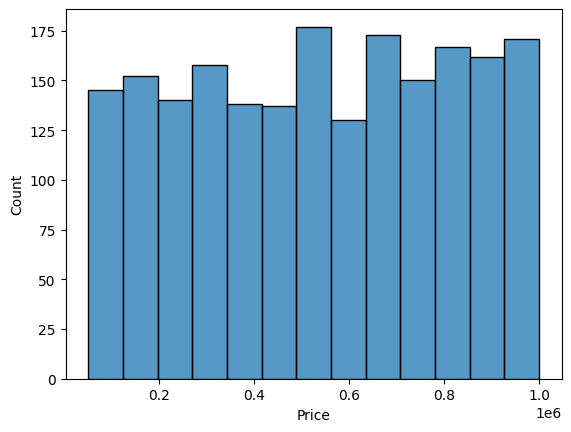

In [4]:
sns.histplot(df["Price"])
plt.show()

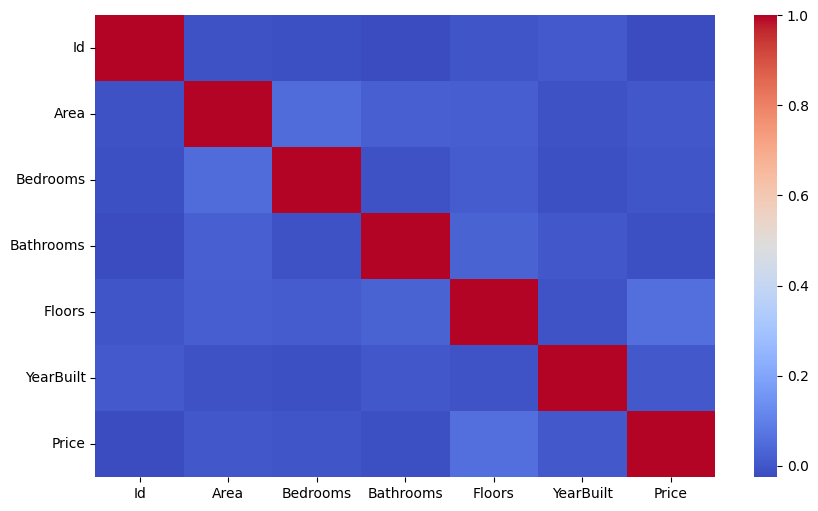

In [6]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap="coolwarm")
plt.show()

In [8]:
df["Price"] = np.log1p(df["Price"])

In [9]:
df["HouseAge"] = 2025 - df["YearBuilt"]

In [11]:
X = df[["Area", "Bedrooms", "Bathrooms", "Floors", "HouseAge"]]

y = df["Price"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [13]:
model = LinearRegression()

model.fit(X_train, y_train)

pred = model.predict(X_test)

In [14]:
ridge = Ridge()

ridge.fit(X_train, y_train)

pred_ridge = ridge.predict(X_test)

In [15]:
lasso = Lasso()

lasso.fit(X_train, y_train)

pred_lasso = lasso.predict(X_test)

In [16]:
rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

RMSE: 0.751010524193734
MAE: 0.6021663137266592
R2 Score: -0.010206173890008774


In [17]:
new_house = [[8000,7,2005,900,2]]

price = model.predict(new_house)

print("Predicted House Price:", price)

Predicted House Price: [15.7579303]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
